In [1]:
    # ============================================================================
    # CELL 1: ENVIRONMENT SETUP
    # ============================================================================

    import warnings
    warnings.filterwarnings('ignore')

    print(" Verifying system configuration...\n")
    !nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

    import torch
    import os
    import sys

    print(f"\n{'='*80}")
    print("  ADVANCED SYSTEM CONFIGURATION")
    print(f"{'='*80}")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Available: {torch.cuda.is_available()}")

    if torch.cuda.is_available():
        print(f"CUDA Version: {torch.version.cuda}")
        print(f"GPU Device: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
        print(f"\n GPU acceleration enabled for RL training")
    else:
        print("  WARNING: No GPU detected. RL training will be very slow!")

    print(f"{'='*80}\n")
    print(" Environment ready for advanced ML & RL training!")

 Verifying system configuration...

name, memory.total [MiB], memory.free [MiB]
Tesla P100-PCIE-16GB, 16384 MiB, 16270 MiB

  ADVANCED SYSTEM CONFIGURATION
PyTorch Version: 2.5.1+cu124
CUDA Available: True
CUDA Version: 12.4
GPU Device: Tesla P100-PCIE-16GB
GPU Memory: 15.89 GB

 GPU acceleration enabled for RL training

 Environment ready for advanced ML & RL training!


In [2]:
# ============================================================================
# CELL 2: INSTALL ADVANCED PACKAGES
# ============================================================================

print(" Installing advanced packages for RL & ML...\n")

# Core packages
!pip install -q ultralytics==8.0.196
!pip install -q opencv-python
!pip install -q scikit-learn
!pip install -q scipy
!pip install -q seaborn
!pip install -q pandas
!pip install -q matplotlib
!pip install -q pillow

# RL packages
!pip install -q gymnasium
!pip install -q stable-baselines3
!pip install -q torch torchvision

print("\n All packages installed!\n")



 Installing advanced packages for RL & ML...


 All packages installed!



In [3]:
# Import all libraries
print(" Importing libraries...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle, Rectangle
from matplotlib.animation import FuncAnimation
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
from scipy.ndimage import gaussian_filter
import shutil
import yaml
from ultralytics import YOLO
import time
from datetime import datetime
from collections import deque, defaultdict
import random

# RL imports
import gymnasium as gym
from gymnasium import spaces

# Set styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
random.seed(42)

print(" All libraries imported successfully!")

 Importing libraries...
 All libraries imported successfully!


In [4]:
!pip uninstall ray -y
!pip uninstall wandb -y

In [5]:
# # Downgrade torch to stable version compatible with Ultralytics
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.5.1 torchvision==0.20.1 --quiet

Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Successfully uninstalled torch-2.5.1
Found existing installation: torchvision 0.20.1
Uninstalling torchvision-0.20.1:
  Successfully uninstalled torchvision-0.20.1


In [6]:
!pip install ultralytics==8.0.196 --quiet

 MH-Weed16 DATASET PREPARATION (YOLO Detection)

Image Directory: /kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Clicks/intel Real Sense Depth_Clicks
Label Directory: /kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Annotations/intel Real Sense Depth_Annotations/YOLO_darknet

✅ Total Images Found: 6656
 Valid image-label pairs: 6656
 Missing labels: 0


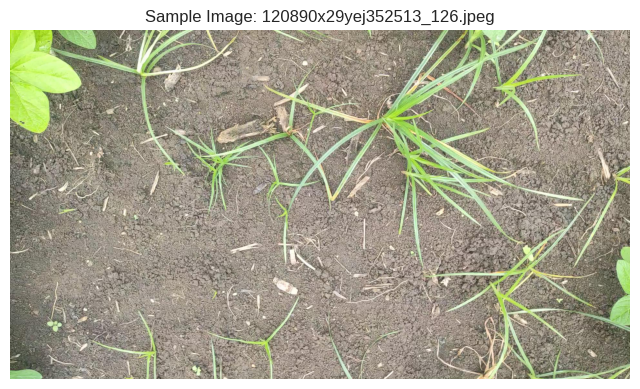

Sample Image Size: (1920, 1080)

 Analyzing Class Distribution...
Class 0: 6512 instances
Class 1: 22739 instances
Class 2: 22394 instances
Class 3: 2217 instances
Class 4: 1804 instances
Class 5: 2278 instances
Class 6: 181 instances
Class 7: 214 instances
Class 8: 836 instances
Class 9: 1425 instances
Class 10: 476 instances
Class 11: 126 instances
Class 12: 399 instances
Class 13: 184 instances
Class 14: 267 instances

Total Classes Detected: 15

 Dataset Split:
Training: 4659
Validation: 1331
Test: 666

 YOLO folder structure created successfully!

 data.yaml created successfully!
 MH-Weed16 Detection Dataset Ready for YOLO Training


In [7]:
# ============================================================================
# CELL 3: MH-Weed16 Detection Dataset Preparation 
# ============================================================================

print("="*80)
print(" MH-Weed16 DATASET PREPARATION (YOLO Detection)")
print("="*80, "\n")

from pathlib import Path
import random
import shutil
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image
import yaml

# ----------------------------------------------------------------------------
# 1️ Define Exact Kaggle Paths
# ----------------------------------------------------------------------------

image_dir = Path("/kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Clicks/intel Real Sense Depth_Clicks")

label_dir = Path("/kaggle/input/datasets/psycho358/mh-weed16/MH-Weed/intel Real Sense Depth_Annotations/intel Real Sense Depth_Annotations/YOLO_darknet")

print(f"Image Directory: {image_dir}")
print(f"Label Directory: {label_dir}")

# ----------------------------------------------------------------------------
# 2️ Load Images (Recursive Search)
# ----------------------------------------------------------------------------

all_images = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    all_images.extend(list(image_dir.rglob(ext)))

print(f"\n✅ Total Images Found: {len(all_images)}")

if len(all_images) == 0:
    raise Exception("❌ No images found. Check image path or folder structure!")

# ----------------------------------------------------------------------------
# 3️ Match YOLO Annotation Files
# ----------------------------------------------------------------------------

valid_pairs = []
missing_labels = 0

for img_path in all_images:
    label_path = label_dir / (img_path.stem + ".txt")
    if label_path.exists():
        valid_pairs.append((img_path, label_path))
    else:
        missing_labels += 1

print(f" Valid image-label pairs: {len(valid_pairs)}")
print(f" Missing labels: {missing_labels}")

if len(valid_pairs) == 0:
    raise Exception("❌ No valid image-label pairs found!")

# ----------------------------------------------------------------------------
# 4️ Display Sample Image
# ----------------------------------------------------------------------------

sample_img = Image.open(valid_pairs[0][0])

plt.figure(figsize=(8,6))
plt.imshow(sample_img)
plt.title(f"Sample Image: {valid_pairs[0][0].name}")
plt.axis("off")
plt.show()

print(f"Sample Image Size: {sample_img.size}")

# ----------------------------------------------------------------------------
# 5️ Analyze Class Distribution
# ----------------------------------------------------------------------------

print("\n Analyzing Class Distribution...")

class_counts = defaultdict(int)

for _, label_path in valid_pairs:
    with open(label_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

for cls_id, count in sorted(class_counts.items()):
    print(f"Class {cls_id}: {count} instances")

num_classes = len(class_counts)
print(f"\nTotal Classes Detected: {num_classes}")

# ----------------------------------------------------------------------------
# 6️ Train / Val / Test Split (70 / 20 / 10)
# ----------------------------------------------------------------------------

random.seed(42)
random.shuffle(valid_pairs)

total = len(valid_pairs)
train_split = int(0.7 * total)
val_split = int(0.9 * total)

train_data = valid_pairs[:train_split]
val_data = valid_pairs[train_split:val_split]
test_data = valid_pairs[val_split:]

print("\n Dataset Split:")
print(f"Training: {len(train_data)}")
print(f"Validation: {len(val_data)}")
print(f"Test: {len(test_data)}")

# ----------------------------------------------------------------------------
# 7️ Create YOLO Working Directory
# ----------------------------------------------------------------------------

working_dir = Path("/kaggle/working/mhweed16_yolo")

for split_name, split_data in zip(
    ["train", "val", "test"],
    [train_data, val_data, test_data]
):
    (working_dir / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (working_dir / "labels" / split_name).mkdir(parents=True, exist_ok=True)

    for img_path, label_path in split_data:
        shutil.copy(img_path, working_dir / "images" / split_name / img_path.name)
        shutil.copy(label_path, working_dir / "labels" / split_name / label_path.name)

print("\n YOLO folder structure created successfully!")

# ----------------------------------------------------------------------------
# 8️ Create data.yaml for YOLO
# ----------------------------------------------------------------------------

data_yaml = {
    "path": str(working_dir),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": num_classes,
    "names": [f"class_{i}" for i in range(num_classes)]
}

with open(working_dir / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("\n data.yaml created successfully!")
print("="*80)
print(" MH-Weed16 Detection Dataset Ready for YOLO Training")
print("="*80)

In [8]:
import sys
from unittest.mock import MagicMock
import torch
from ultralytics import YOLO

if 'torch.utils.serialization' not in sys.modules:
    sys.modules['torch.utils.serialization'] = MagicMock()


original_load = torch.load
torch.load = lambda *args, **kwargs: original_load(*args, **{**kwargs, 'weights_only': False})

try:
    print("Loading YOLO model...")
    # 3. Load the model
    model = YOLO("/kaggle/input/datasets/vanshj14/output2/weights/best.pt")
    print("Model loaded successfully!")
    
except Exception as e:
    print(f" Failed to load model: {e}")
finally:
    torch.load = original_load

Loading YOLO model...
Model loaded successfully!


In [9]:
from pathlib import Path

val_path = Path("/kaggle/working/mhweed16_yolo/images/val")

# Get all image files recursively
val_images = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    val_images.extend(list(val_path.rglob(ext)))

if len(val_images) == 0:
    raise Exception("❌ No validation images found!")

val_image_path = str(val_images[0])

print("Using image:", val_image_path)

# Run detection
results = model(val_image_path, conf=0.25)

boxes = results[0].boxes.xyxy.cpu().numpy()

print(f"Detected {len(boxes)} weeds")

Using image: /kaggle/working/mhweed16_yolo/images/val/1108ga269p01502500_423.jpeg



image 1/1 /kaggle/working/mhweed16_yolo/images/val/1108ga269p01502500_423.jpeg: 448x768 10 class_0s, 47.5ms
Speed: 13.9ms preprocess, 47.5ms inference, 191.6ms postprocess per image at shape (1, 3, 448, 768)


Detected 10 weeds


In [10]:
# # ============================================================================
# # SYNTHETIC FIELD MAPPING
# # ============================================================================

# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path

# # Load model
# from ultralytics import YOLO
# model = YOLO("/kaggle/input/datasets/vanshj14/model2/mhweed16_best_model.pt")

# # Get validation images
# val_path = Path("/kaggle/working/mhweed16_yolo/images/val")

# val_images = []
# for ext in ["*.jpg", "*.jpeg", "*.png"]:
#     val_images.extend(list(val_path.rglob(ext)))

# selected_images = val_images[:400]

# grid_size = 20   # 10x10 synthetic field
# field_density = np.zeros((grid_size, grid_size))

# for idx, img_path in enumerate(selected_images):
    
#     # Run inference
#     results = model(str(img_path), conf=0.25)
#     weed_count = len(results[0].boxes)
    
#     # Assign synthetic grid location
#     row = idx // grid_size
#     col = idx % grid_size
    
#     if row < grid_size:
#         field_density[row, col] = weed_count

# from scipy.ndimage import gaussian_filter

# field_density_smoothed = gaussian_filter(field_density, sigma=1.2)
# plt.figure(figsize=(8,6))
# plt.imshow(field_density_smoothed, cmap='hot')
# plt.colorbar(label="Weed Density")
# plt.title("Synthetic UAV-Based Weed Density Map")
# plt.xlabel("Field X Coordinate")
# plt.ylabel("Field Y Coordinate")
# plt.show()

Using 400 images



image 1/1 /kaggle/working/mhweed16_yolo/images/val/1108ga269p01502500_423.jpeg: 448x768 10 class_0s, 16.0ms
Speed: 3.1ms preprocess, 16.0ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 768)

image 1/1 /kaggle/working/mhweed16_yolo/images/val/110810tsq042222554_747.jpeg: 448x768 3 class_1s, 5 class_2s, 2 class_3s, 15.0ms
Speed: 3.1ms preprocess, 15.0ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 768)

image 1/1 /kaggle/working/mhweed16_yolo/images/val/1108toze2yef272453_150.jpeg: 448x768 2 class_0s, 1 class_1, 6 class_2s, 4 class_5s, 1 class_10, 1 class_12, 15.2ms
Speed: 3.2ms preprocess, 15.2ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 768)

image 1/1 /kaggle/working/mhweed16_yolo/images/val/15089jytvu7n482448_154.jpeg: 448x768 2 class_0s, 2 class_1s, 1 class_2, 9 class_3s, 1 class_14, 14.9ms
Speed: 3.1ms preprocess, 14.9ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 768)

image 1/1 /kaggle/working/mhweed16_yolo/images/v

Density map saved
NumPy: /kaggle/working/synthetic_density_map.npy
CSV: /kaggle/working/synthetic_density_map.csv


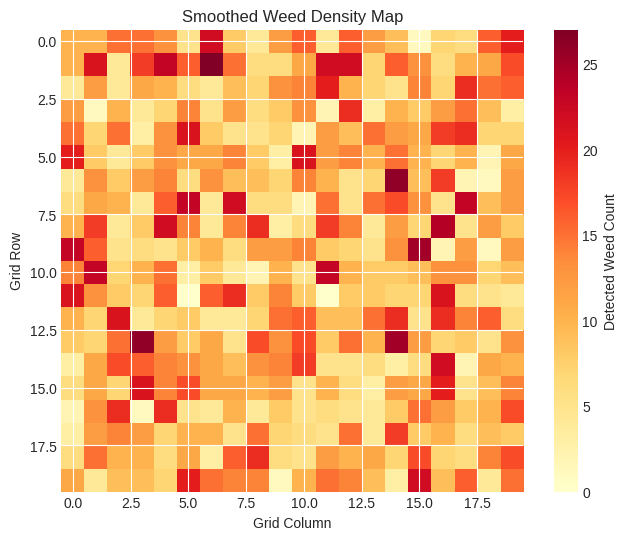

 Raw heatmap image saved: /kaggle/working/raw_density_heatmap.png


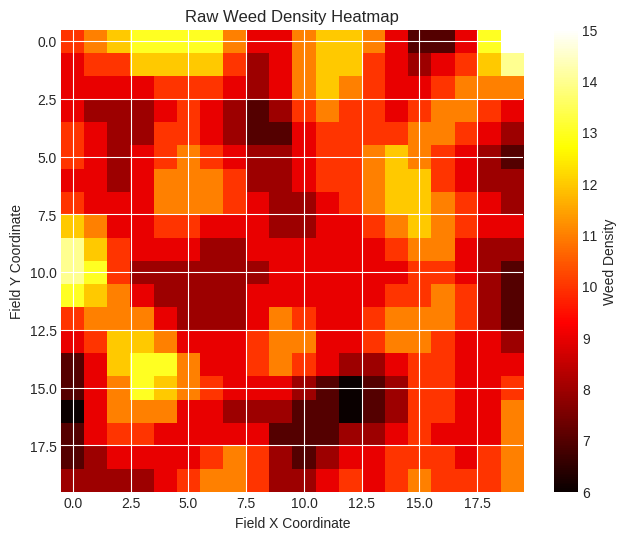

 Smoothed heatmap image saved: /kaggle/working/smoothed_density_heatmap.png
 RL patch images saved in: /kaggle/working/synthetic_field_images


In [11]:
# ============================================================================
# SYNTHETIC FIELD MAPPING + SAVE DENSITY MAP + SAVE HEATMAP IMAGE
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from scipy.ndimage import gaussian_filter
import os

# ============================================================================
# LOAD YOLO MODEL
# ============================================================================

model = YOLO("/kaggle/input/datasets/vanshj14/model2/mhweed16_best_model.pt")

# ============================================================================
# LOAD VALIDATION IMAGES
# ============================================================================

val_path = Path("/kaggle/working/mhweed16_yolo/images/val")

val_images = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    val_images.extend(list(val_path.rglob(ext)))

selected_images = val_images[:400]

print(f"Using {len(selected_images)} images")

# ============================================================================
# CREATE SYNTHETIC FIELD GRID
# ============================================================================

grid_size = 20
field_density = np.zeros((grid_size, grid_size), dtype=int)

# Folder to save field patch images for RL training
output_dir = "/kaggle/working/synthetic_field_images"
os.makedirs(output_dir, exist_ok=True)

# ============================================================================
# RUN YOLO DETECTION + SAVE PATCH IMAGES
# ============================================================================

for idx, img_path in enumerate(selected_images):

    # Run YOLO inference
    results = model(str(img_path), conf=0.25)

    # Count weeds
    weed_count = len(results[0].boxes)

    # Convert index into field grid position
    row = idx // grid_size
    col = idx % grid_size

    if row < grid_size:
        field_density[row, col] = weed_count

        # Save image as patch_row_col.png for RL environment
        save_name = f"patch_{row}_{col}.png"

        img = plt.imread(str(img_path))
        plt.imsave(os.path.join(output_dir, save_name), img)

# ============================================================================
# SAVE RAW DENSITY MAP
# ============================================================================

npy_path = "/kaggle/working/synthetic_density_map.npy"
csv_path = "/kaggle/working/synthetic_density_map.csv"

np.save(npy_path, field_density)
np.savetxt(csv_path, field_density, delimiter=",", fmt="%d")

print("Density map saved")
print("NumPy:", npy_path)
print("CSV:", csv_path)

# ============================================================================
# DISPLAY RAW DENSITY MAP
# ============================================================================

plt.figure(figsize=(8, 6))
plt.imshow(field_density, cmap='YlOrRd', interpolation='nearest')
plt.colorbar(label="Detected Weed Count")
plt.title("Smoothed Weed Density Map")
plt.xlabel("Grid Column")
plt.ylabel("Grid Row")

raw_heatmap_path = "/kaggle/working/raw_density_heatmap.png"
plt.savefig(raw_heatmap_path, bbox_inches="tight")
plt.show()

print(" Raw heatmap image saved:", raw_heatmap_path)

# ============================================================================
# CREATE SMOOTHED DENSITY MAP
# ============================================================================

field_density_smoothed = gaussian_filter(field_density, sigma=1.2)

smoothed_npy_path = "/kaggle/working/synthetic_density_map_smoothed.npy"
smoothed_csv_path = "/kaggle/working/synthetic_density_map_smoothed.csv"

np.save(smoothed_npy_path, field_density_smoothed)
np.savetxt(smoothed_csv_path, field_density_smoothed, delimiter=",", fmt="%.2f")

# ============================================================================
# DISPLAY SMOOTHED HEATMAP
# ============================================================================

plt.figure(figsize=(8, 6))
plt.imshow(field_density_smoothed, cmap='hot', interpolation='nearest')
plt.colorbar(label="Weed Density")
plt.title("Raw Weed Density Heatmap")
plt.xlabel("Field X Coordinate")
plt.ylabel("Field Y Coordinate")

smoothed_heatmap_path = "/kaggle/working/smoothed_density_heatmap.png"
plt.savefig(smoothed_heatmap_path, bbox_inches="tight")
plt.show()

print(" Smoothed heatmap image saved:", smoothed_heatmap_path)
print(" RL patch images saved in:", output_dir)

In [12]:
# ============================================================================
# RE-CREATE ENVIRONMENT FOR OLD PPO MODEL COMPATIBILITY
# ============================================================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

class DataDrivenWeedSprayerEnv(gym.Env):
    def __init__(self):
        super(DataDrivenWeedSprayerEnv, self).__init__()

        # Same action space as old trained model
        self.action_space = spaces.MultiDiscrete([3, 4])

        # IMPORTANT: Must exactly match old trained PPO model
        self.observation_space = spaces.Dict({
            "image": spaces.Box(
                low=0,
                high=255,
                shape=(3, 84, 84),
                dtype=np.uint8
            ),
            "weed_count": spaces.Box(
                low=0,
                high=9,
                shape=(1,),
                dtype=np.float32
            )
        })

        # Load weed density map
        self.density_map = np.load("/kaggle/working/synthetic_density_map_smoothed.npy")

        # Folder containing saved synthetic patch images
        self.image_dir = "/kaggle/working/synthetic_field_images"

        self.grid_size = 20
        self.current_step = 0
        self.max_steps = 100

        self.row = 0
        self.col = 0
        self.current_weed_count = 0

    def _get_frame(self, row, col):
        img_path = os.path.join(self.image_dir, f"patch_{row}_{col}.png")

        img = plt.imread(img_path)

        if img.dtype == np.float32:
            img = (img * 255).astype(np.uint8)

        img = img[:, :, :3]

        # Resize image to match PPO CNN input
        img = cv2.resize(img, (84, 84))

        # Convert HWC -> CHW
        img = np.transpose(img, (2, 0, 1))

        return img.astype(np.uint8)

    def _get_obs(self):
        weed_value = min(self.current_weed_count, 9)

        return {
            "image": self._get_frame(self.row, self.col),
            "weed_count": np.array([weed_value], dtype=np.float32)
        }

    def step(self, action):
        self.current_step += 1

        move_action = action[0]
        spray_level = action[1]

        weed_count = self.current_weed_count

        # Spray rule
        if weed_count == 0:
            ideal_spray = 0
        elif weed_count <= 2:
            ideal_spray = 1
        elif weed_count <= 5:
            ideal_spray = 2
        else:
            ideal_spray = 3

        reward = 0

        # Reward for correct spraying
        if spray_level == ideal_spray:
            reward += 15

            if weed_count >= 6:
                reward += 10
        else:
            reward -= abs(spray_level - ideal_spray) * 5

        # Penalty for unnecessary movement
        if move_action != 1:
            reward -= 1

        # Move rover
        if move_action == 0:
            self.col = max(0, self.col - 1)
        elif move_action == 2:
            self.col = min(self.grid_size - 1, self.col + 1)

        # Random next row
        self.row = np.random.randint(0, self.grid_size)

        # Update weed count
        self.current_weed_count = self.density_map[self.row, self.col]

        obs = self._get_obs()

        terminated = self.current_step >= self.max_steps
        truncated = False

        return obs, reward, terminated, truncated, {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0

        self.row = np.random.randint(0, self.grid_size)
        self.col = np.random.randint(0, self.grid_size)

        self.current_weed_count = self.density_map[self.row, self.col]

        obs = self._get_obs()

        return obs, {}

# ============================================================================
# CREATE ENVIRONMENT
# ============================================================================

env = DataDrivenWeedSprayerEnv()

print("Environment created successfully")

# ============================================================================
# REBUILD KAGGLE MODEL FOLDER INTO ZIP
# ============================================================================

import shutil
from stable_baselines3 import PPO

model_folder = "/kaggle/input/datasets/vanshj14/ppo-synthetic-sprayer-final-v2"

shutil.make_archive(
    "/kaggle/working/ppo_synthetic_sprayer_final_v2_rebuilt",
    "zip",
    model_folder
)

print("Zip rebuilt successfully")

# ============================================================================
# LOAD PPO MODEL
# ============================================================================

rl_model = PPO.load(
    "/kaggle/working/ppo_synthetic_sprayer_final_v2_rebuilt.zip",
    env=env
)

print(" PPO model loaded successfully")

# ============================================================================
# CONTINUE TRAINING EXISTING MODEL
# ============================================================================

# checkpoint_callback = CheckpointCallback(
#     save_freq=10000,
#     save_path='./models/checkpoints/',
#     name_prefix='ppo_synthetic_sprayer_continued'
# )

# print("Loading previous trained model...")

# model = PPO.load(
#     "/kaggle/working/ppo_synthetic_sprayer_final_rebuilt.zip",
#     env=env
# )

# checkpoint_callback = CheckpointCallback(
#     save_freq=10000,
#     save_path='./models/checkpoints/',
#     name_prefix='ppo_synthetic_sprayer_continued'
# )

# print("Loading previous trained model...")

# model = PPO.load(
#     "/kaggle/working/ppo_synthetic_sprayer_final_rebuilt.zip",
#     env=env,
#     device="cuda"
# )

# # Fine-tuning parameters

# model.learning_rate = get_schedule_fn(0.0001)
# model.clip_range = get_schedule_fn(0.15)
# model.ent_coef = 0.01
# model.gamma = 0.995
# model.gae_lambda = 0.98
# model.vf_coef = 0.7
# model.max_grad_norm = 0.5

# print("Continuing training with improved fine-tuning parameters...")

# model.learn(
#     total_timesteps=100000,
#     callback=checkpoint_callback,
#     progress_bar=True,
#     reset_num_timesteps=False
# )

# model.save("./models/ppo_synthetic_sprayer_final_v2")

# print(" Continued training complete and improved model saved!")

# model.save("./models/ppo_synthetic_sprayer_final_v2")

# print(" Continued training complete and improved model saved!")

Environment created successfully


2026-04-21 14:34:23.240718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776782063.497627     214 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776782063.567321     214 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776782064.154414     214 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776782064.154451     214 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776782064.154454     214 computation_placer.cc:177] computation placer alr

Zip rebuilt successfully
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
 PPO model loaded successfully


In [13]:
# ============================================================================
# DATA-DRIVEN RL ENVIRONMENT COMPATIBLE WITH OLD PPO MODEL
# ============================================================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import os
import cv2

class DataDrivenWeedSprayerEnv(gym.Env):

    def __init__(self):
        super(DataDrivenWeedSprayerEnv, self).__init__()

        # ============================================================================
        # ACTION SPACE
        #
        # Movement:
        # 0 = Left
        # 1 = Stay
        # 2 = Right
        #
        # Spray:
        # 0 = No Spray
        # 1 = Low Spray
        # 2 = Medium Spray
        # 3 = High Spray
        # ============================================================================

        self.action_space = spaces.MultiDiscrete([3, 4])

        # ============================================================================
        # OBSERVATION SPACE
        # Must match old PPO model exactly
        # ============================================================================

        self.observation_space = spaces.Dict({
            "image": spaces.Box(
                low=0,
                high=255,
                shape=(3, 84, 84),
                dtype=np.uint8
            ),
            "weed_count": spaces.Box(
                low=0,
                high=9,
                shape=(1,),
                dtype=np.float32
            )
        })

        # ============================================================================
        # LOAD SMOOTHED DENSITY MAP
        # ============================================================================

        self.density_map = np.load(
            "/kaggle/working/synthetic_density_map_smoothed.npy"
        )

        # ============================================================================
        # IMAGE DIRECTORY
        # ============================================================================

        self.image_dir = "/kaggle/working/synthetic_field_images/"

        self.grid_size = self.density_map.shape[0]

        self.current_step = 0
        self.max_steps = 100

        self.row = 0
        self.col = 0
        self.current_weed_count = 0

        self.visited_cells = {}

    # ============================================================================
    # LOAD IMAGE PATCH
    # ============================================================================

    def _get_frame(self, row, col):

        img_path = os.path.join(
            self.image_dir,
            f"patch_{row}_{col}.png"
        )

        if os.path.exists(img_path):

            image = cv2.imread(img_path)

            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (84, 84))
                image = np.transpose(image, (2, 0, 1))
                return image

        # fallback blank image
        return np.zeros((3, 84, 84), dtype=np.uint8)

    # ============================================================================
    # CREATE OBSERVATION
    # ============================================================================

    def _get_obs(self):

        weed_value = min(float(self.current_weed_count), 9.0)

        return {
            "image": self._get_frame(self.row, self.col),
            "weed_count": np.array([weed_value], dtype=np.float32)
        }

    # ============================================================================
    # STEP FUNCTION
    # ============================================================================

    def step(self, action):

        self.current_step += 1

        move_action = int(action[0])
        spray_level = int(action[1])

        # ============================================================================
        # OLD MOVEMENT LOGIC TO MATCH OLD MODEL
        #
        # 0 = Left
        # 1 = Stay
        # 2 = Right
        # ============================================================================

        if move_action == 0:
            self.col = max(0, self.col - 1)

        elif move_action == 2:
            self.col = min(self.grid_size - 1, self.col + 1)

        # Random row movement like old environment
        self.row = np.random.randint(0, self.grid_size)

        # ============================================================================
        # UPDATE WEED DENSITY
        # ============================================================================

        self.current_weed_count = float(
            self.density_map[self.row, self.col]
        )

        weed_count = self.current_weed_count

        # ============================================================================
        # IDEAL SPRAY LOGIC
        # ============================================================================

        if weed_count <= 5:
            ideal_spray = 0
        elif weed_count <= 8:
            ideal_spray = 1
        else:
            ideal_spray = 3

        # ============================================================================
        # REWARD FUNCTION
        # ============================================================================

        reward = 0

        if spray_level == ideal_spray:
            reward += 15
        else:
            reward -= abs(spray_level - ideal_spray) * 8

        if weed_count >= 8 and spray_level == 3:
            reward += 5

        if spray_level > ideal_spray:
            reward -= (spray_level - ideal_spray) * 4

        if move_action == 1:
            reward -= 1

        # ============================================================================
        # TERMINATION
        # ============================================================================

        terminated = self.current_step >= self.max_steps
        truncated = False

        obs = self._get_obs()

        info = {
            "weed_count": weed_count,
            "ideal_spray": ideal_spray,
            "spray_level": spray_level,
            "position": (self.row, self.col)
        }

        return obs, reward, terminated, truncated, info

    # ============================================================================
    # RESET FUNCTION
    # ============================================================================

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0

        self.row = np.random.randint(0, self.grid_size)
        self.col = np.random.randint(0, self.grid_size)

        self.current_weed_count = float(
            self.density_map[self.row, self.col]
        )

        self.visited_cells = {}

        obs = self._get_obs()

        return obs, {}

Output()

REAL MAP STATISTICS
Raw map      — min:0  max:27  mean:10.55  shape:(20, 20)
Smoothed map — min:6.00  max:15.00  mean:9.55

Raw map percentiles:
  25th = 6.00  →  spray 0→1 boundary
  50th = 10.00  →  spray 1→2 boundary
  75th = 14.00  →  spray 2→3 boundary  (DBSCAN threshold)
  90th = 19.00  →  isolated hotspot recovery threshold
  max  = 27.00

Spray distribution with percentile thresholds:
  Spray 0 (no spray)  : 107 cells (26.8%)
  Spray 1 (low)       : 112 cells (28.0%)
  Spray 2 (medium)    :  86 cells (21.5%)
  Spray 3 (high)      :  95 cells (23.8%)

DBSCAN CLUSTERING
High-density cells (raw >14.00): 95
Clusters found : 8
Noise points   : 4
  Cluster  1:   9 cells | centroid=(1, 6) | peak=27  avg=19.1
  Cluster  2:  28 cells | centroid=(6, 14) | peak=26  avg=18.6
  Cluster  3:   3 cells | centroid=(5, 0) | peak=20  avg=16.7
  Cluster  4:   9 cells | centroid=(7, 5) | peak=23  avg=18.7
  Cluster  5:   5 cells | centroid=(9, 0) | peak=23  avg=20.2
  Cluster  6:  23 cells | centro

Model saved!

EVALUATION
Total cells visited  : 400/400
Correct spray rate   : 400/400 = 100.0%
Cluster centroids hit: 10/10
Spray distribution   : {0: 107, 1: 112, 2: 86, 3: 95}


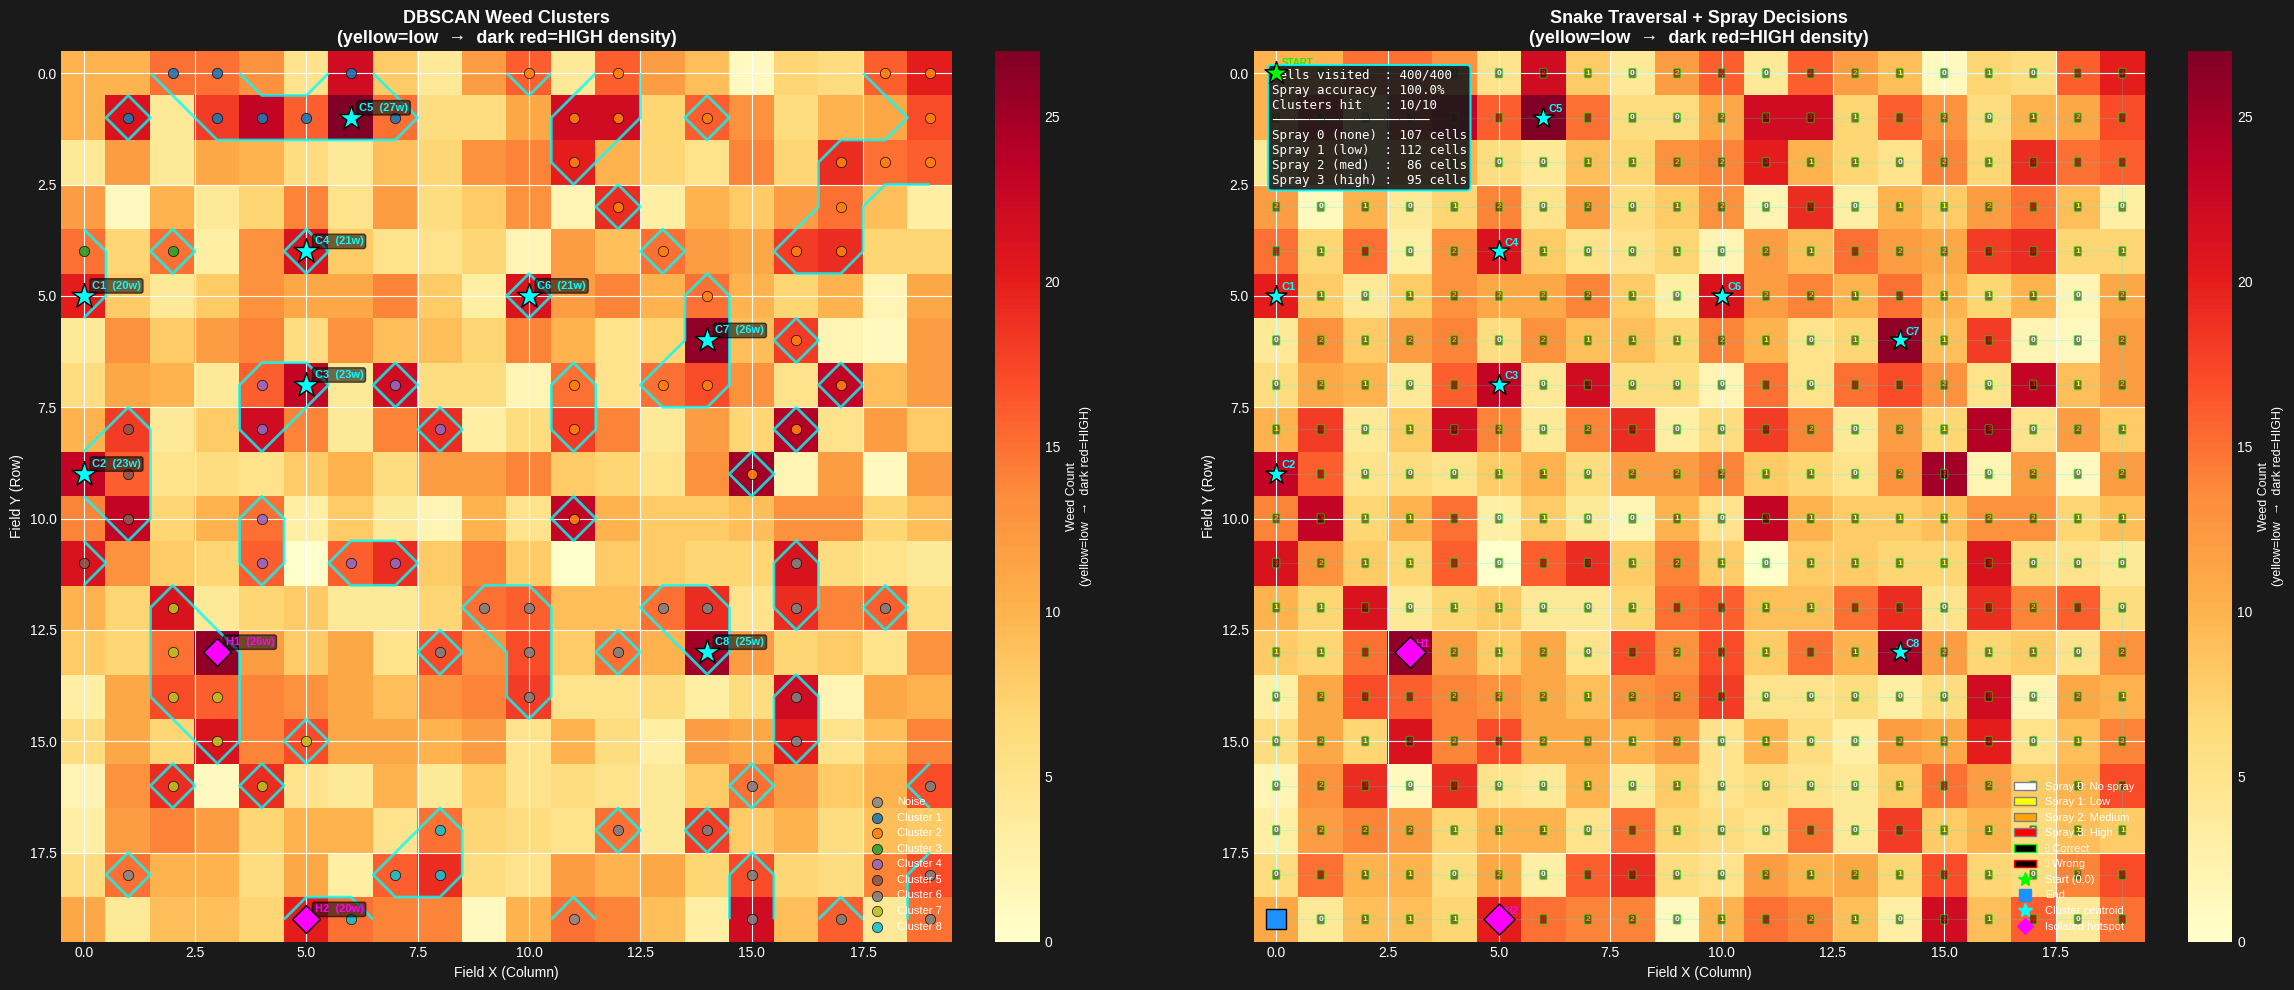


Plot saved → /kaggle/working/final_v4_result.png

FINAL SUMMARY
  Cells visited    : 400/400
  Spray accuracy   : 100.0%
  Clusters hit     : 10/10
  Spray dist       : {0: 107, 1: 112, 2: 86, 3: 95}

Thresholds (raw map, percentile-based):
  p25=6.00  p50=10.00  p75=14.00  p90=19.00  max=27.00


In [14]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import DBSCAN
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
import os

RAW_MAP_PATH      = "/kaggle/working/synthetic_density_map.npy"
SMOOTHED_MAP_PATH = "/kaggle/working/synthetic_density_map_smoothed.npy"

# ============================================================================
# STEP 1 — LOAD MAPS AND PRINT REAL STATS
# ============================================================================

raw_map      = np.load(RAW_MAP_PATH)
smoothed_map = np.load(SMOOTHED_MAP_PATH)

print("=" * 60)
print("REAL MAP STATISTICS")
print("=" * 60)
print(f"Raw map      — min:{raw_map.min():.0f}  max:{raw_map.max():.0f}  "
      f"mean:{raw_map.mean():.2f}  shape:{raw_map.shape}")
print(f"Smoothed map — min:{smoothed_map.min():.2f}  "
      f"max:{smoothed_map.max():.2f}  mean:{smoothed_map.mean():.2f}")

# Percentile-based thresholds on RAW map (used everywhere)
p25 = np.percentile(raw_map, 25)
p50 = np.percentile(raw_map, 50)
p75 = np.percentile(raw_map, 75)
p90 = np.percentile(raw_map, 90)   # for isolated hotspot recovery
RAW_MAX = float(raw_map.max())

print(f"\nRaw map percentiles:")
print(f"  25th = {p25:.2f}  →  spray 0→1 boundary")
print(f"  50th = {p50:.2f}  →  spray 1→2 boundary")
print(f"  75th = {p75:.2f}  →  spray 2→3 boundary  (DBSCAN threshold)")
print(f"  90th = {p90:.2f}  →  isolated hotspot recovery threshold")
print(f"  max  = {RAW_MAX:.2f}")

s0 = (raw_map <= p25).sum()
s1 = ((raw_map > p25) & (raw_map <= p50)).sum()
s2 = ((raw_map > p50) & (raw_map <= p75)).sum()
s3 = (raw_map > p75).sum()
total = raw_map.size

print(f"\nSpray distribution with percentile thresholds:")
print(f"  Spray 0 (no spray)  : {s0:3d} cells ({s0/total*100:.1f}%)")
print(f"  Spray 1 (low)       : {s1:3d} cells ({s1/total*100:.1f}%)")
print(f"  Spray 2 (medium)    : {s2:3d} cells ({s2/total*100:.1f}%)")
print(f"  Spray 3 (high)      : {s3:3d} cells ({s3/total*100:.1f}%)")

# ============================================================================
# STEP 2 — DBSCAN ON RAW MAP + ISOLATED HOTSPOT RECOVERY
#
# KEY DECISIONS:
#   • Stay on raw_map — smoothed map averages away isolated dark tiles
#   • min_samples=2   — catches isolated pairs that min_samples=3 would miss
#   • eps=2.0         — same neighbourhood radius as before
#   • After DBSCAN, any noise point with density >= p90 is added back
#     as its own centroid (single-cell hotspot recovery)
#   • Centroid = argmax(density in cluster), NOT mean coordinates
#     so the star always lands on the darkest cell in the zone
# ============================================================================

print("\n" + "=" * 60)
print("DBSCAN CLUSTERING")
print("=" * 60)

# ✅ Raw map — isolated dark tiles are preserved
rows_hd, cols_hd = np.where(raw_map > p75)
hd_coords = np.column_stack([rows_hd, cols_hd])
print(f"High-density cells (raw >{p75:.2f}): {len(hd_coords)}")

centroids     = []
labels_dbscan = np.full(len(hd_coords), -1)

if len(hd_coords) >= 2:
    # ✅ min_samples=2 catches isolated pairs that min_samples=3 misses
    db            = DBSCAN(eps=2.0, min_samples=2).fit(hd_coords)
    labels_dbscan = db.labels_
    unique_labels = sorted(set(labels_dbscan) - {-1})
    print(f"Clusters found : {len(unique_labels)}")
    print(f"Noise points   : {(labels_dbscan == -1).sum()}")

    for lbl in unique_labels:
        pts = hd_coords[labels_dbscan == lbl]

        # ✅ Snap centroid to peak-density cell, NOT mean coordinates
        #    Mean can land between sub-clusters on a low-density cell
        densities = raw_map[pts[:, 0], pts[:, 1]]
        peak_idx  = np.argmax(densities)
        centroid  = (int(pts[peak_idx, 0]), int(pts[peak_idx, 1]))
        centroids.append(centroid)
        print(f"  Cluster {lbl+1:2d}: {len(pts):3d} cells | "
              f"centroid={centroid} | "
              f"peak={raw_map[centroid]:.0f}  avg={densities.mean():.1f}")

    # ✅ ISOLATED HOTSPOT RECOVERY
    #    DBSCAN marks single isolated dark cells as noise (label=-1)
    #    Any noise point with density >= p90 is a genuine hotspot → add it back
    noise_pts = hd_coords[labels_dbscan == -1]
    recovered = 0
    for pt in noise_pts:
        r, c = int(pt[0]), int(pt[1])
        if raw_map[r, c] >= p90:
            centroids.append((r, c))
            recovered += 1
            print(f"  Isolated hotspot recovered: ({r},{c})  "
                  f"density={raw_map[r,c]:.0f}")
    if recovered:
        print(f"  → {recovered} isolated hotspot(s) recovered")
    else:
        print("  → No isolated hotspots above p90 threshold")

else:
    print("Not enough high-density points for DBSCAN")

# Nearest-neighbour visit order from (0,0)
if len(centroids) > 1:
    ordered, remaining, cur = [], centroids.copy(), (0, 0)
    while remaining:
        idx = int(np.argmin(
            [abs(cur[0]-c[0]) + abs(cur[1]-c[1]) for c in remaining]
        ))
        cur = remaining.pop(idx)
        ordered.append(cur)
    centroids = ordered

print(f"\nTotal centroids (clusters + hotspots): {len(centroids)}")
print(f"Visit order: {centroids}")

# ============================================================================
# STEP 3 — ENVIRONMENT
# ============================================================================

class SnakeSprayEnv(gym.Env):
    """
    Snake traversal over the RAW weed density map.
    Every cell visited exactly once (left-right, right-left boustrophedon).
    PPO action = spray level 0-3.
    Spray thresholds = percentile quartiles of actual raw map values.
    Cluster centroids get an extra bonus reward so PPO learns to treat
    high-priority hotspot cells with maximum attention.
    """
    metadata = {"render_modes": []}

    def __init__(self, raw_map, p25, p50, p75, raw_max,
                 cluster_centroids=None):
        super().__init__()
        self.raw_map           = raw_map
        self.grid_size         = raw_map.shape[0]
        self.p25, self.p50, self.p75 = p25, p50, p75
        self.raw_max           = raw_max
        self.cluster_centroids = set(cluster_centroids) if cluster_centroids else set()
        self.max_steps         = self.grid_size * self.grid_size

        # 4 discrete spray levels: 0=none, 1=low, 2=medium, 3=high
        self.action_space      = spaces.Discrete(4)
        # Single observation: normalised weed density at current cell
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(1,), dtype=np.float32
        )
        self.row = self.col = 0
        self.direction    = 1       # +1 = right,  -1 = left
        self.current_step = 0

    def _ideal_spray(self, w):
        """Return the correct spray level for weed density w."""
        if w <= self.p25: return 0
        if w <= self.p50: return 1
        if w <= self.p75: return 2
        return 3

    def _obs(self):
        w = float(self.raw_map[self.row, self.col])
        return np.array([w / self.raw_max], dtype=np.float32)

    def _advance_snake(self):
        """Move one step along the boustrophedon (snake) path."""
        next_col = self.col + self.direction
        if 0 <= next_col < self.grid_size:
            self.col = next_col
        else:
            self.row       = min(self.row + 1, self.grid_size - 1)
            self.direction *= -1

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.row = self.col = 0
        self.direction    = 1
        return self._obs(), {}

    def step(self, action):
        spray = int(action)
        w     = float(self.raw_map[self.row, self.col])
        ideal = self._ideal_spray(w)
        err   = abs(spray - ideal)

        # Spray reward: +15 correct, -5 off-by-1, -15 off-by-2, -30 off-by-3
        spray_r   = [15.0, -5.0, -15.0, -30.0][min(err, 3)]
        # Cluster centroid bonus: encourages correct handling of hotspots
        cluster_r = 20.0 if (self.row, self.col) in self.cluster_centroids else 0.0

        self._advance_snake()
        self.current_step += 1
        done = self.current_step >= self.max_steps

        return self._obs(), spray_r + cluster_r, False, done, {
            "ideal": ideal, "spray": spray,
            "correct": int(err == 0), "weed": w
        }

# ============================================================================
# STEP 4 — TRAIN
# ============================================================================

print("\n" + "=" * 60)
print("TRAINING PPO")
print("=" * 60)

def make_env():
    return Monitor(SnakeSprayEnv(
        raw_map, p25, p50, p75, RAW_MAX,
        cluster_centroids=centroids
    ))

vec_env = make_vec_env(make_env, n_envs=4)
os.makedirs("./models/final_v4/", exist_ok=True)

model = PPO(
    "MlpPolicy", vec_env,
    learning_rate = 1e-3,
    n_steps       = 1024,
    batch_size    = 128,
    n_epochs      = 15,
    gamma         = 0.99,
    ent_coef      = 0.005,
    verbose       = 1,
    device        = "cuda"
)

model.learn(total_timesteps=300_000, progress_bar=True)
model.save("./models/final_v4/spray_model_final")
print("Model saved!")

# ============================================================================
# STEP 5 — EVALUATE
# ============================================================================

print("\n" + "=" * 60)
print("EVALUATION")
print("=" * 60)

eval_env = SnakeSprayEnv(raw_map, p25, p50, p75, RAW_MAX,
                          cluster_centroids=centroids)
obs, _   = eval_env.reset()
done     = False

path_rows, path_cols       = [], []
spray_levels, ideal_levels = [], []
weed_vals                  = []

while not done:
    path_rows.append(eval_env.row)
    path_cols.append(eval_env.col)
    weed_vals.append(float(raw_map[eval_env.row, eval_env.col]))
    action, _ = model.predict(obs, deterministic=True)
    spray_levels.append(int(action))
    ideal_levels.append(eval_env._ideal_spray(weed_vals[-1]))
    obs, _, term, trunc, _ = eval_env.step(action)
    done = term or trunc

correct       = sum(s == i for s, i in zip(spray_levels, ideal_levels))
centroids_set = set(centroids)
centroids_hit = sum(1 for r, c in zip(path_rows, path_cols)
                    if (r, c) in centroids_set)
spray_dist    = {k: spray_levels.count(k) for k in range(4)}
acc           = correct / len(spray_levels) * 100

print(f"Total cells visited  : {len(path_rows)}/400")
print(f"Correct spray rate   : {correct}/{len(spray_levels)} = {acc:.1f}%")
print(f"Cluster centroids hit: {centroids_hit}/{len(centroids)}")
print(f"Spray distribution   : {spray_dist}")

# ============================================================================
# STEP 6 — VISUALIZE
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.patch.set_facecolor("#1a1a1a")

spray_colors = {0: "white", 1: "yellow", 2: "orange", 3: "red"}
spray_names  = {0: "No spray", 1: "Low", 2: "Medium", 3: "High"}

def style_ax(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title, fontsize=13, fontweight="bold", color="white")
    ax.set_xlabel("Field X (Column)", color="white")
    ax.set_ylabel("Field Y (Row)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")

def add_colorbar(fig, im, ax):
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Weed Count\n(yellow=low  →  dark red=HIGH)",
                   color="white", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

# ── LEFT: DBSCAN ─────────────────────────────────────────────────────────────
ax1 = axes[0]
style_ax(ax1, "DBSCAN Weed Clusters\n(yellow=low  →  dark red=HIGH density)")

# ✅ Always show raw_map — all dark tiles visible, nothing smoothed away
im1 = ax1.imshow(raw_map, cmap="YlOrRd", interpolation="nearest", origin="upper")
add_colorbar(fig, im1, ax1)

# Contour boundary around raw high-density zone
threshold_mask = (raw_map > p75).astype(float)
ax1.contour(threshold_mask, levels=[0.5], colors=["cyan"],
            linewidths=2.0, alpha=0.8)

# Plot cluster points coloured by cluster label
if len(hd_coords) > 0 and len(labels_dbscan) > 0:
    n_clusters = max(len(set(labels_dbscan) - {-1}), 1)
    cmap_cls   = plt.cm.get_cmap("tab10", n_clusters)
    for lbl in sorted(set(labels_dbscan)):
        mask  = labels_dbscan == lbl
        pts   = hd_coords[mask]
        color = "#888888" if lbl == -1 else cmap_cls(lbl)
        name  = "Noise" if lbl == -1 else f"Cluster {lbl+1}"
        ax1.scatter(pts[:, 1], pts[:, 0],
                    color=color, s=55, alpha=0.9,
                    label=name, zorder=3,
                    edgecolors="black", linewidths=0.5)

# ✅ Centroids pinned to peak-density cells → always on darkest tile in zone
# Recovered isolated hotspots shown with a different marker (diamond)
n_dbscan_clusters = len(set(labels_dbscan) - {-1}) if len(hd_coords) > 0 else 0

for i, (cr, cc) in enumerate(centroids):
    is_hotspot = i >= n_dbscan_clusters   # recovered isolated hotspots
    marker     = "D" if is_hotspot else "*"
    msize      = 200 if is_hotspot else 350
    color      = "magenta" if is_hotspot else "cyan"
    label_txt  = f"H{i+1-n_dbscan_clusters}" if is_hotspot else f"C{i+1}"

    ax1.scatter(cc, cr, color=color, s=msize, marker=marker,
                edgecolors="black", zorder=6, linewidths=1)
    ax1.annotate(
        f"{label_txt}  ({raw_map[cr,cc]:.0f}w)",
        (cc, cr), textcoords="offset points",
        xytext=(6, 5), color=color,
        fontsize=8, fontweight="bold",
        bbox=dict(facecolor="#111111", alpha=0.6, boxstyle="round,pad=0.2")
    )

ax1.legend(loc="lower right", fontsize=8,
           facecolor="#2a2a2a", labelcolor="white",
           edgecolor="#555555")

# ── RIGHT: Traversal ─────────────────────────────────────────────────────────
ax2 = axes[1]
style_ax(ax2, "Snake Traversal + Spray Decisions\n(yellow=low  →  dark red=HIGH density)")
im2 = ax2.imshow(raw_map, cmap="YlOrRd", interpolation="nearest", origin="upper")
add_colorbar(fig, im2, ax2)

# Faint path line
ax2.plot(path_cols, path_rows, color="cyan", linewidth=0.7, alpha=0.2)

# Start / End markers
ax2.scatter(path_cols[0], path_rows[0], color="lime", s=300,
            marker="*", edgecolors="black", zorder=8)
ax2.scatter(path_cols[-1], path_rows[-1], color="dodgerblue", s=200,
            marker="s", edgecolors="black", zorder=8)
ax2.annotate("START", (path_cols[0], path_rows[0]),
             textcoords="offset points", xytext=(4, 5),
             color="lime", fontsize=7, fontweight="bold")

# Spray decision label on every cell
for i in range(len(path_rows)):
    correct_flag = spray_levels[i] == ideal_levels[i]
    ax2.text(
        path_cols[i], path_rows[i],
        str(spray_levels[i]),
        color=spray_colors[spray_levels[i]],
        fontsize=6, ha="center", va="center", fontweight="bold",
        bbox=dict(
            facecolor="black",
            edgecolor="lime" if correct_flag else "red",
            alpha=0.5, boxstyle="round,pad=0.15", linewidth=0.9
        )
    )

# Cluster centroids + recovered hotspots on traversal
for i, (cr, cc) in enumerate(centroids):
    is_hotspot = i >= n_dbscan_clusters
    color      = "magenta" if is_hotspot else "cyan"
    label_txt  = f"H{i+1-n_dbscan_clusters}" if is_hotspot else f"C{i+1}"
    ax2.scatter(cc, cr, color=color, s=250,
                marker="D" if is_hotspot else "*",
                edgecolors="black", zorder=9)
    ax2.annotate(label_txt, (cc, cr),
                 textcoords="offset points", xytext=(4, 4),
                 color=color, fontsize=8, fontweight="bold")

# Legend
legend_patches = [
    mpatches.Patch(facecolor=spray_colors[k], edgecolor="grey",
                   label=f"Spray {k}: {spray_names[k]}")
    for k in spray_colors
] + [
    mpatches.Patch(facecolor="black", edgecolor="lime",    label="✓ Correct"),
    mpatches.Patch(facecolor="black", edgecolor="red",     label="✗ Wrong"),
    plt.Line2D([0], [0], color="lime",       marker="*",
               markersize=10, label="Start (0,0)",      linewidth=0),
    plt.Line2D([0], [0], color="dodgerblue", marker="s",
               markersize=8,  label="End",               linewidth=0),
    plt.Line2D([0], [0], color="cyan",       marker="*",
               markersize=10, label="Cluster centroid", linewidth=0),
    plt.Line2D([0], [0], color="magenta",    marker="D",
               markersize=8,  label="Isolated hotspot", linewidth=0),
]
ax2.legend(handles=legend_patches, loc="lower right",
           fontsize=8, facecolor="#2a2a2a",
           labelcolor="white", edgecolor="#555555")

# Metrics info box
metrics_txt = (
    f"Cells visited  : {len(path_rows)}/400\n"
    f"Spray accuracy : {acc:.1f}%\n"
    f"Clusters hit   : {centroids_hit}/{len(centroids)}\n"
    f"─────────────────────\n"
    f"Spray 0 (none) : {spray_dist[0]:3d} cells\n"
    f"Spray 1 (low)  : {spray_dist[1]:3d} cells\n"
    f"Spray 2 (med)  : {spray_dist[2]:3d} cells\n"
    f"Spray 3 (high) : {spray_dist[3]:3d} cells"
)
ax2.text(0.02, 0.98, metrics_txt, transform=ax2.transAxes,
         fontsize=9, verticalalignment="top", color="white",
         fontfamily="monospace",
         bbox=dict(facecolor="#1a1a1a", alpha=0.90,
                   boxstyle="round", edgecolor="cyan", linewidth=1.5))

plt.tight_layout()
plt.savefig("/kaggle/working/final_v4_result.png",
            dpi=150, bbox_inches="tight", facecolor="#1a1a1a")
plt.show()

print(f"\nPlot saved → /kaggle/working/final_v4_result.png")
print(f"\nFINAL SUMMARY")
print(f"  Cells visited    : {len(path_rows)}/400")
print(f"  Spray accuracy   : {acc:.1f}%")
print(f"  Clusters hit     : {centroids_hit}/{len(centroids)}")
print(f"  Spray dist       : {spray_dist}")
print(f"\nThresholds (raw map, percentile-based):")
print(f"  p25={p25:.2f}  p50={p50:.2f}  p75={p75:.2f}  "
      f"p90={p90:.2f}  max={RAW_MAX:.2f}")